# 01 · Data Loading & Cleaning

**Purpose:** Pull raw data from PostgreSQL, clean it, and persist to parquet.

**Outputs:** `companies.parquet`, `stock_prices.parquet`, `articles.parquet`,
`sentiments.parquet`, `company_mentions.parquet`, `sector_mentions.parquet`

In [1]:
import re
import sys
from pathlib import Path

import pandas as pd

# Make utils importable from this notebook's directory
NB_DIR = Path().resolve()
sys.path.insert(0, str(NB_DIR))
from utils import query, save, DATA_DIR

print(f"PostgreSQL data  →  {DATA_DIR}")

PostgreSQL data  →  C:\_PROJECTS\pfa_bvc\Notebooks\signal_pipeline\data


## 1 · Companies

In [2]:
def load_companies() -> pd.DataFrame:
    return query("""
        SELECT ticker, company_name, sector, parent,
               description, ceo, founded, headquarters,
               revenue, employees, stock_exchange, siege_social
        FROM companies
        ORDER BY ticker
    """)

companies = load_companies()
print(f"{len(companies)} companies")
companies.head()

73 companies


C:\_PROJECTS\pfa_bvc\Notebooks\signal_pipeline\utils.py:42: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


,ticker,company_name,sector,parent,description,ceo,founded,headquarters,revenue,employees,stock_exchange,siege_social
0,ADH,Addoha Group,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ADI,Alliances Développement Immobilier,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AFI,Afric Industries,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AFM,AFMA,Insurance,Independent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AGM,AGMA,Insurance,Independent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2 · Stock Prices

In [3]:
def load_stock_prices() -> pd.DataFrame:
    df = query("""
        SELECT ticker, date, close, open, high, low, volume, change_pct
        FROM stock_prices
        ORDER BY ticker, date
    """)
    df["date"] = pd.to_datetime(df["date"])
    df[["close", "open", "high", "low", "volume", "change_pct"]] = (
        df[["close", "open", "high", "low", "volume", "change_pct"]].apply(pd.to_numeric, errors="coerce")
    )
    return df

stock_prices = load_stock_prices()
print(f"{len(stock_prices):,} rows  |  {stock_prices['ticker'].nunique()} tickers")
print(f"Date range: {stock_prices['date'].min().date()} → {stock_prices['date'].max().date()}")
stock_prices.head()

C:\_PROJECTS\pfa_bvc\Notebooks\signal_pipeline\utils.py:42: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


42,702 rows  |  46 tickers
Date range: 2021-01-04 → 2026-05-13


,ticker,date,close,open,high,low,volume,change_pct
0,ADH,2021-01-04,6.45,6.59,6.59,6.36,170680.0,0.94
1,ADH,2021-01-05,6.57,6.49,6.60,6.45,93820.0,1.86
2,ADH,2021-01-06,6.72,6.57,6.80,6.56,367630.0,2.28
3,ADH,2021-01-07,6.70,6.74,6.79,6.65,293190.0,-0.30
4,ADH,2021-01-08,6.65,6.74,6.77,6.56,25200.0,-0.75


## 3 · Articles

In [4]:
def clean_text(text) -> str:
    """Strip HTML tags and collapse whitespace."""
    if not isinstance(text, str):
        return ""
    text = re.sub(r"<[^>]+>", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def load_articles() -> pd.DataFrame:
    df = query("""
        SELECT a.url, a.title, a.published_at, a.full_text,
               a.language, a.feed_url, f.name AS feed_name
        FROM   articles a
        LEFT JOIN feeds f ON f.url = a.feed_url
        WHERE  a.published_at IS NOT NULL
    """)
    df["published_at"] = pd.to_datetime(df["published_at"], utc=True)
    # Timezone-naive calendar date for joining with prices
    df["date"] = df["published_at"].dt.tz_localize(None).dt.normalize()
    df["title"]     = df["title"].apply(clean_text)
    df["full_text"] = df["full_text"].apply(clean_text)
    # Combined text for matching and event detection
    df["text"] = (df["title"].fillna("") + " " + df["full_text"].fillna("")).str.strip()
    df = df.drop_duplicates(subset=["url"])
    return df

articles = load_articles()
print(f"{len(articles):,} articles")
print(f"Date range: {articles['date'].min().date()} → {articles['date'].max().date()}")
print(f"Languages: {articles['language'].value_counts().to_dict()}")
articles[["url", "title", "date", "language", "feed_name"]].head()

C:\_PROJECTS\pfa_bvc\Notebooks\signal_pipeline\utils.py:42: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


1,456 articles
Date range: 2006-09-20 → 2026-05-21
Languages: {'fr': 1175, 'ar': 281}


,url,title,date,language,feed_name
0,https://lematin.ma/nation/hausse-des-prix-nadi...,Hausse des prix : Nadia Fettah met en garde co...,2026-04-19,fr,LeMatin Economie
1,https://lematin.ma/nation/prix-des-carburants-...,"Prix des carburants, GMT+1... Leïla Benali exp...",2026-04-19,fr,LeMatin Economie
2,https://lematin.ma/societe/ia-a-lecole-un-levi...,IA à l’école : un levier d’apprentissage qui i...,2026-04-19,fr,LeMatin Economie
3,https://lematin.ma/nation/siam-2026-entretien-...,SIAM 2026 : la ministre de l’Agriculture Annie...,2026-04-19,fr,LeMatin Economie
4,https://lematin.ma/sports/el-ouahdi-et-boufal-...,Lions de l’Atlas : El Ouahdi et Boufal buteurs...,2026-04-19,fr,LeMatin Economie


## 4 · Sentiment Scores

In [5]:
def load_sentiments() -> pd.DataFrame:
    df = query("""
SELECT ss.article_url, sentiment, score, confidence, reasoning, analyzed_at,
               event_type, event_fingerprint FROM public.article_events as ae 
join events as e 
on ae.event_fingerprint = e.fingerprint
join sentiment_scores as ss
on ss.article_url = ae.article_url
    """)
    df["analyzed_at"] = pd.to_datetime(df["analyzed_at"], utc=True)
    df["score"]       = pd.to_numeric(df["score"], errors="coerce")
    df["confidence"]  = pd.to_numeric(df["confidence"], errors="coerce")
    # Fallback: columns may not exist in older PG schema
    if "event_type" not in df.columns:
        df["event_type"] = None
    if "event_fingerprint" not in df.columns:
        df["event_fingerprint"] = None
    return df

sentiments = load_sentiments()
print(f"{len(sentiments):,} sentiment scores")
print(f"event_type coverage: {sentiments['event_type'].notna().sum()} / {len(sentiments)}")
sentiments["sentiment"].value_counts()

54 sentiment scores
event_type coverage: 54 / 54


C:\_PROJECTS\pfa_bvc\Notebooks\signal_pipeline\utils.py:42: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


sentiment
positive    31
neutral     16
negative     7
Name: count, dtype: int64

## 5 · Entity Mentions

In [6]:
def load_company_mentions() -> pd.DataFrame:
    return query("""
        SELECT m.article_url, m.ticker, c.company_name, c.sector
        FROM   article_company_mentions m
        LEFT JOIN companies c ON c.ticker = m.ticker
    """)

def load_sector_mentions() -> pd.DataFrame:
    return query("""
        SELECT article_url, sector_name
        FROM   article_sector_mentions
    """)

company_mentions = load_company_mentions()
sector_mentions  = load_sector_mentions()
print(f"Company mentions: {len(company_mentions):,}")
print(f"Sector mentions:  {len(sector_mentions):,}")
company_mentions.head()

C:\_PROJECTS\pfa_bvc\Notebooks\signal_pipeline\utils.py:42: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


Company mentions: 103
Sector mentions:  172


,article_url,ticker,company_name,sector
0,https://lematin.ma/economie/la-bei-accelere-se...,ADI,Alliances Développement Immobilier,NaN
1,https://lematin.ma/economie/la-bei-accelere-se...,ATL,AtlantaSanad,Insurance
2,https://www.lavieeco.com/affaires/biscuiterie-...,AFI,Afric Industries,NaN
3,https://www.lavieeco.com/comese/srm-casablanca...,SRM,Societe de Réalisations Mécaniques,NaN
4,https://telquel.ma/instant-t/2026/05/19/bourse...,AFI,Afric Industries,NaN


## 6 · Neo4j — Events

Load `:Event` nodes and their `INVOLVES` company links from the Neo4j graph.
These are LLM-extracted events that were deduplicated across articles.

In [7]:
from utils import neo4j_query

def load_events_neo4j() -> pd.DataFrame:
    return neo4j_query("""
        MATCH (e:Event)
        OPTIONAL MATCH (e)-[:INVOLVES]->(c:Company)
        RETURN e.fingerprint   AS fingerprint,
               e.event_type    AS event_type,
               e.event_date    AS event_date,
               e.article_count AS article_count,
               e.first_seen    AS first_seen,
               collect(c.ticker) AS involved_tickers
    """)

events_neo4j = load_events_neo4j()
print(f"{len(events_neo4j):,} Event nodes in Neo4j")
if not events_neo4j.empty:
    print(events_neo4j["event_type"].value_counts().to_string())
events_neo4j.head()

30 Event nodes in Neo4j
event_type
market_data           8
strategic_plan        8
project_contract      3
regulatory_action     3
economic_indicator    2
capital_operation     2
earnings_release      1
ipo_listing           1
leadership_change     1
debt_issuance         1


,fingerprint,event_type,event_date,article_count,first_seen,involved_tickers
0,1be6d8e35060fdf4,market_data,NaN,4,2026-05-21T23:37:47.821147+00:00,"[GAZ, AFI]"
1,0b6278e4d1986555,economic_indicator,NaN,5,2026-05-21T23:39:30.582052+00:00,[]
2,57e6fce174b584ac,project_contract,NaN,4,2026-05-21T23:39:30.667405+00:00,[]
3,1ef8efc3020c25da,market_data,NaN,5,2026-05-21T23:40:21.096899+00:00,[]
4,3dfa0b515b136ae3,market_data,NaN,2,2026-05-21T23:40:21.192203+00:00,[]


## 7 · Neo4j — People

Load `:Person` nodes and their company associations.

In [8]:
def load_people_neo4j() -> pd.DataFrame:
    return neo4j_query("""
        MATCH (p:Person)
        OPTIONAL MATCH (p)-[:ASSOCIATED_WITH]->(c:Company)
        OPTIONAL MATCH (a:Article)-[:MENTIONS_PERSON]->(p)
        RETURN p.normalized_name AS normalized_name,
               p.name            AS name,
               p.role            AS role,
               count(DISTINCT a) AS article_count,
               collect(DISTINCT c.ticker) AS associated_tickers
    """)

people = load_people_neo4j()
print(f"{len(people):,} Person nodes in Neo4j")
if not people.empty:
    print("\nTop people by article count:")
    print(people.sort_values("article_count", ascending=False).head(10)[
        ["name", "role", "article_count", "associated_tickers"]
    ].to_string(index=False))
people.head()

40 Person nodes in Neo4j

Top people by article count:
                name                                                                  role  article_count associated_tickers
   Abdessamad Kayouh                                   Minister of Transport and Logistics              2                 []
          Mehdi Tazi                                             CGEM leadership candidate              2                 []
      Nasser Bourita                                           Minister of Foreign Affairs              2                 []
        Fouzi Lekjaa                                     Minister délégué chargé du Budget              2                 []
        Leila Benali     Ministre de la Transition énergétique et du Développement durable              2                 []
        Nadia Fettah                                                              Minister              2                 []
        Mohsen Naqvi                                        Minister o

,normalized_name,name,role,article_count,associated_tickers
0,abdelwahed el fellah,Abdelwahed El Fellah,représentant des commerçants du marché de gros...,1,[]
1,driss fedou,Driss Fedou,Président du directoire de Wafasalaf,1,"[GAZ, AFI]"
2,mohsen naqvi,Mohsen Naqvi,"Minister of Interior, Pakistan",1,[]
3,donald trump,Donald Trump,"President, United States",1,[]
4,marco rubio,Marco Rubio,"Secretary of State, United States",1,[]


## 8 · Missing-value summary

In [9]:
def missing_report(df: pd.DataFrame, label: str) -> None:
    missing = df.isna().mean().mul(100).round(1)
    missing = missing[missing > 0]
    if missing.empty:
        print(f"[{label}] no missing values")
    else:
        print(f"[{label}] columns with missing values (%):\n{missing.to_string()}\n")

missing_report(stock_prices, "stock_prices")
missing_report(articles[["url", "title", "full_text", "language"]], "articles")
missing_report(sentiments[["article_url", "sentiment", "score"]], "sentiments")

[stock_prices] no missing values
[articles] no missing values
[sentiments] no missing values


## 9 · Save

In [10]:
save(companies,        "companies")
save(stock_prices,     "stock_prices")
save(articles,         "articles")
save(sentiments,       "sentiments")
save(company_mentions, "company_mentions")
save(sector_mentions,  "sector_mentions")
if not events_neo4j.empty:
    save(events_neo4j, "events_neo4j")
if not people.empty:
    save(people,       "people")

  saved 73 rows  →  companies.parquet
  saved 42,702 rows  →  stock_prices.parquet
  saved 1,456 rows  →  articles.parquet
  saved 54 rows  →  sentiments.parquet
  saved 103 rows  →  company_mentions.parquet
  saved 172 rows  →  sector_mentions.parquet
  saved 30 rows  →  events_neo4j.parquet
  saved 40 rows  →  people.parquet


## 10 · Data overview visuals

Quick dashboards so you can see exactly what's in the pipeline right now.

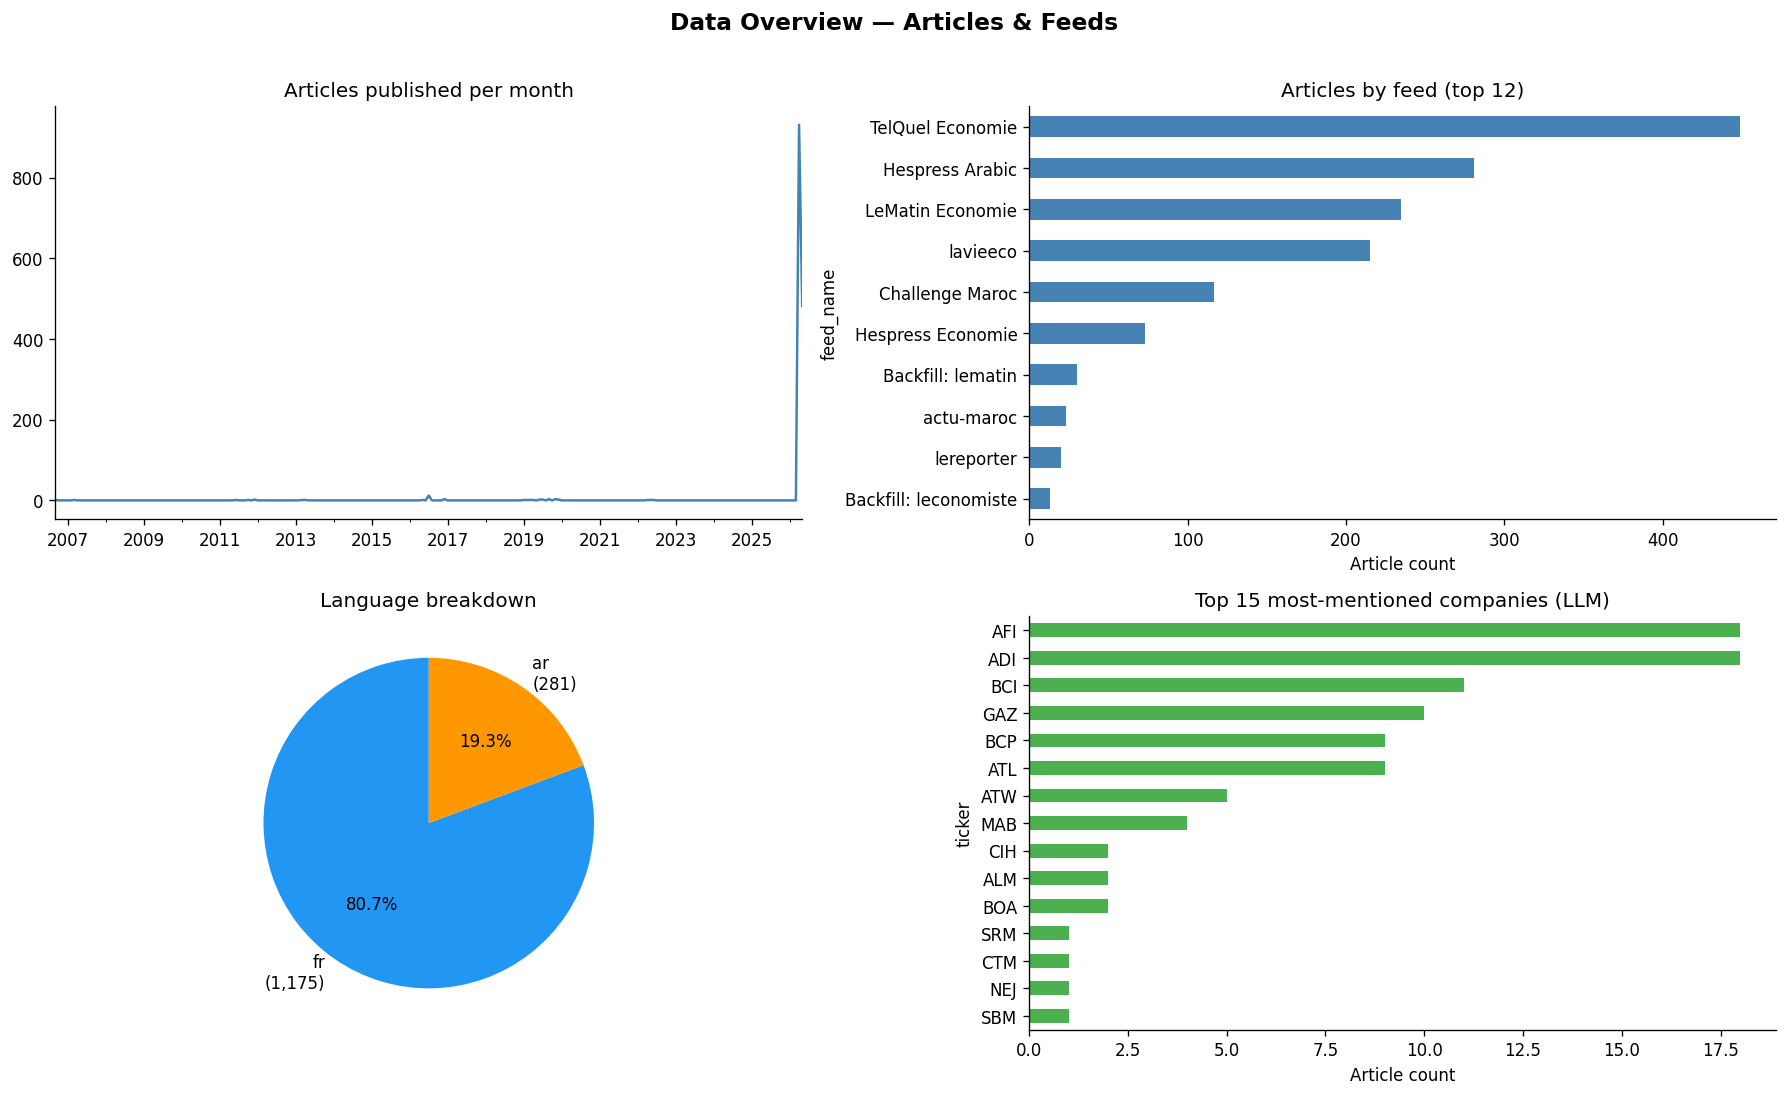

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

# ── Panel 1: Articles per month ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle("Data Overview — Articles & Feeds", fontsize=14, fontweight="bold", y=1.01)

monthly = (
    articles.set_index("published_at")
    .resample("ME")["url"].count()
    .rename("count")
)
monthly.plot(ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Articles published per month")
axes[0, 0].set_xlabel("")
axes[0, 0].yaxis.set_major_formatter(mticker.FormatStrFormatter("%d"))

# ── Panel 2: Articles by feed ─────────────────────────────────────────────────
by_feed = articles["feed_name"].value_counts().head(12)
by_feed.sort_values().plot.barh(ax=axes[0, 1], color="steelblue")
axes[0, 1].set_title("Articles by feed (top 12)")
axes[0, 1].set_xlabel("Article count")

# ── Panel 3: Language breakdown ───────────────────────────────────────────────
lang_counts = articles["language"].value_counts()
axes[1, 0].pie(
    lang_counts,
    labels=[f"{l}\n({n:,})" for l, n in zip(lang_counts.index, lang_counts)],
    autopct="%1.1f%%",
    colors=["#2196F3", "#FF9800"],
    startangle=90,
)
axes[1, 0].set_title("Language breakdown")

# ── Panel 4: Top 15 most-mentioned companies ─────────────────────────────────
top_companies = company_mentions["ticker"].value_counts().head(15)
top_companies.sort_values().plot.barh(ax=axes[1, 1], color="#4CAF50")
axes[1, 1].set_title("Top 15 most-mentioned companies (LLM)")
axes[1, 1].set_xlabel("Article count")

plt.tight_layout()
plt.show()

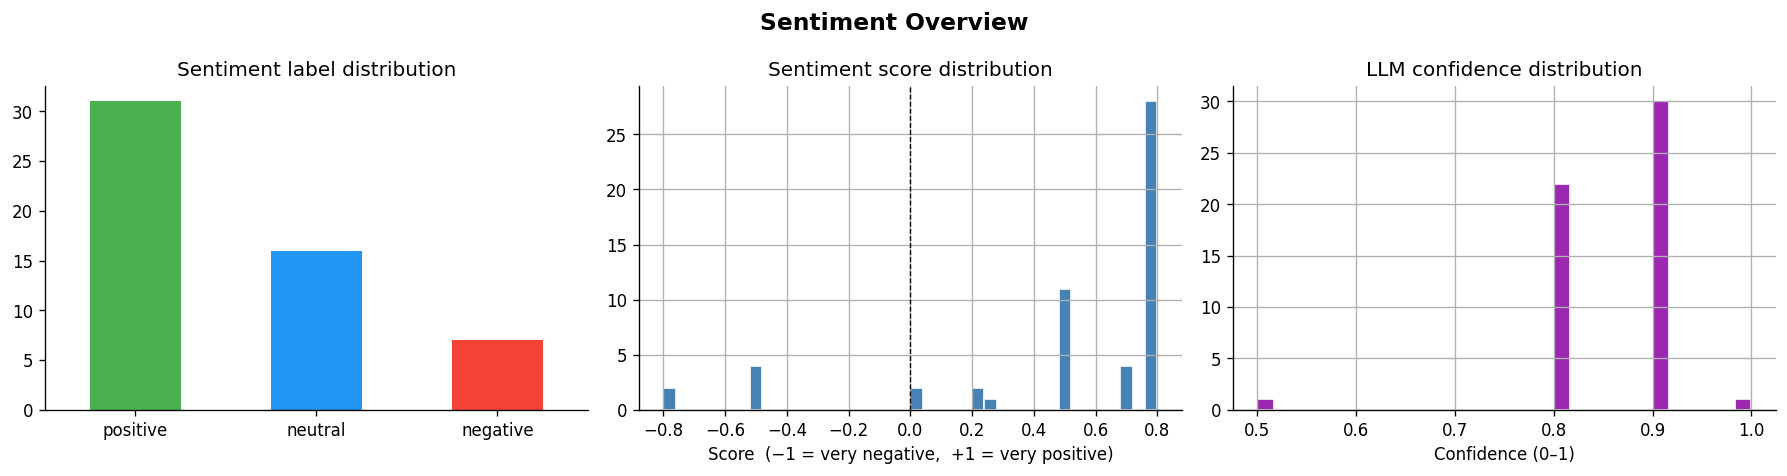

In [12]:
# ── Sentiment overview ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Sentiment Overview", fontsize=14, fontweight="bold")

colors = {"positive": "#4CAF50", "neutral": "#2196F3", "negative": "#F44336"}

sent_counts = sentiments["sentiment"].value_counts()
sent_bar_colors = [colors.get(s, "gray") for s in sent_counts.index]
sent_counts.plot.bar(ax=axes[0], color=sent_bar_colors, rot=0)
axes[0].set_title("Sentiment label distribution")
axes[0].set_xlabel("")

sentiments["score"].hist(bins=40, ax=axes[1], color="steelblue", edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Sentiment score distribution")
axes[1].set_xlabel("Score  (−1 = very negative,  +1 = very positive)")

sentiments["confidence"].hist(bins=30, ax=axes[2], color="#9C27B0", edgecolor="white")
axes[2].set_title("LLM confidence distribution")
axes[2].set_xlabel("Confidence (0–1)")

plt.tight_layout()
plt.show()

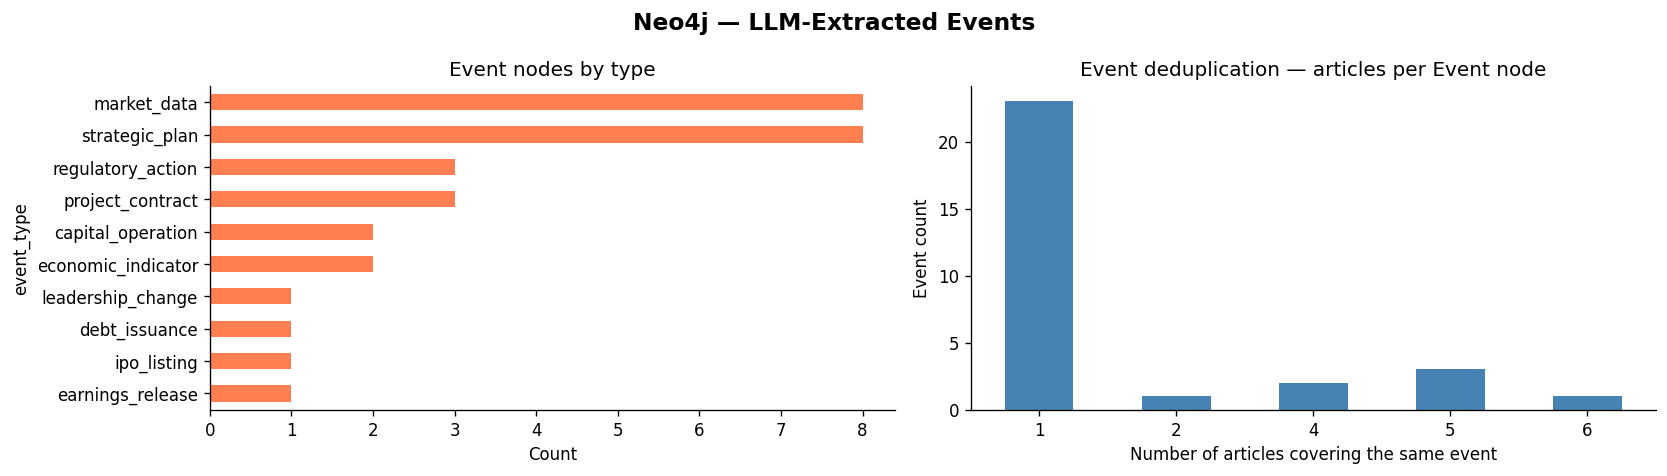

In [13]:
# ── Neo4j Event overview ──────────────────────────────────────────────────────
if not events_neo4j.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle("Neo4j — LLM-Extracted Events", fontsize=14, fontweight="bold")

    et_counts = events_neo4j["event_type"].value_counts()
    et_counts.sort_values().plot.barh(ax=axes[0], color="coral")
    axes[0].set_title("Event nodes by type")
    axes[0].set_xlabel("Count")

    ac = events_neo4j["article_count"].value_counts().sort_index()
    ac.plot.bar(ax=axes[1], color="steelblue", rot=0)
    axes[1].set_title("Event deduplication — articles per Event node")
    axes[1].set_xlabel("Number of articles covering the same event")
    axes[1].set_ylabel("Event count")

    plt.tight_layout()
    plt.show()
else:
    print("No Event nodes found in Neo4j — run the RSS pipeline first.")

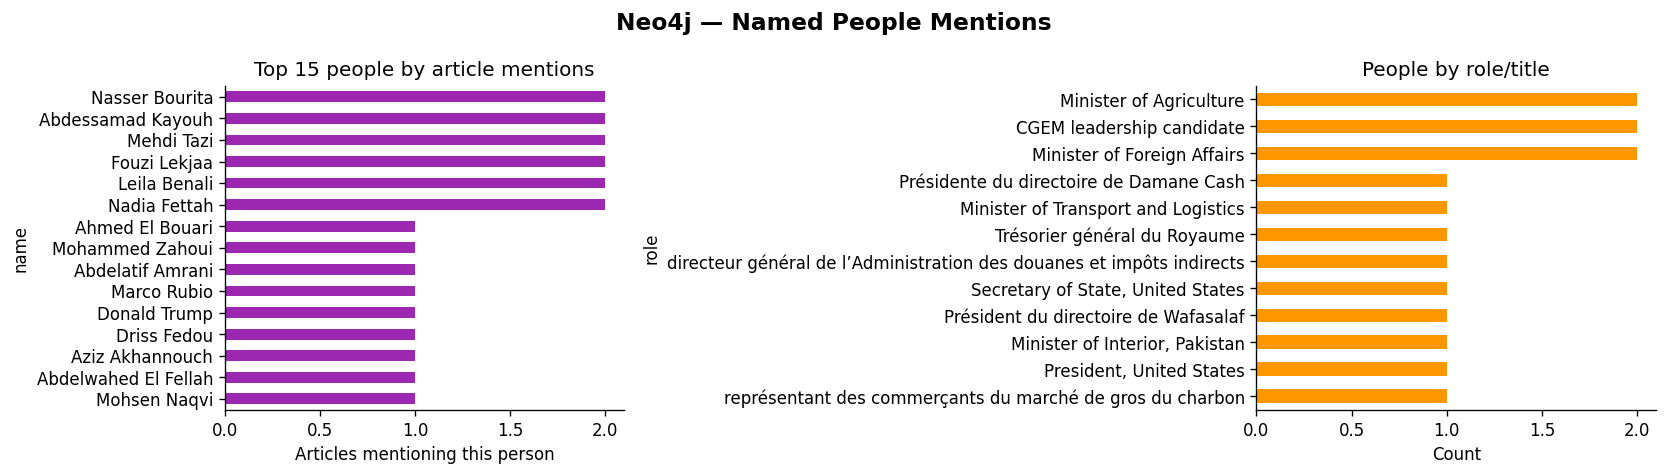

In [14]:
# ── Neo4j People overview ─────────────────────────────────────────────────────
if not people.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle("Neo4j — Named People Mentions", fontsize=14, fontweight="bold")

    top_people = people.sort_values("article_count", ascending=False).head(15)
    top_people.set_index("name")["article_count"].sort_values().plot.barh(
        ax=axes[0], color="#9C27B0"
    )
    axes[0].set_title("Top 15 people by article mentions")
    axes[0].set_xlabel("Articles mentioning this person")

    role_counts = (
        people["role"]
        .replace("", "Unknown")
        .fillna("Unknown")
        .value_counts()
        .head(12)
    )
    role_counts.sort_values().plot.barh(ax=axes[1], color="#FF9800")
    axes[1].set_title("People by role/title")
    axes[1].set_xlabel("Count")

    plt.tight_layout()
    plt.show()
else:
    print("No Person nodes found in Neo4j — run the RSS pipeline first.")